Columnas detectadas: ['cliente_id', 'tipo_zona', 'Suma de churn', 'Avg Satisfaccion', 'tipo_plan', 'Promedio de ingreso_estimado', 'Promedio de importe_total', 'Promedio de antiguedad_meses']
--------------------------------------------------
¡Limpieza completada! Tipos de datos actuales:
Promedio de ingreso_estimado    float64
Promedio de importe_total       float64
Promedio de antiguedad_meses    float64
Suma de churn                     int64
dtype: object
--------------------------------------------------

Datos de entrenamiento: 8000 filas
Datos de prueba: 2000 filas
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1600, number of negative: 6400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 8000, number of use

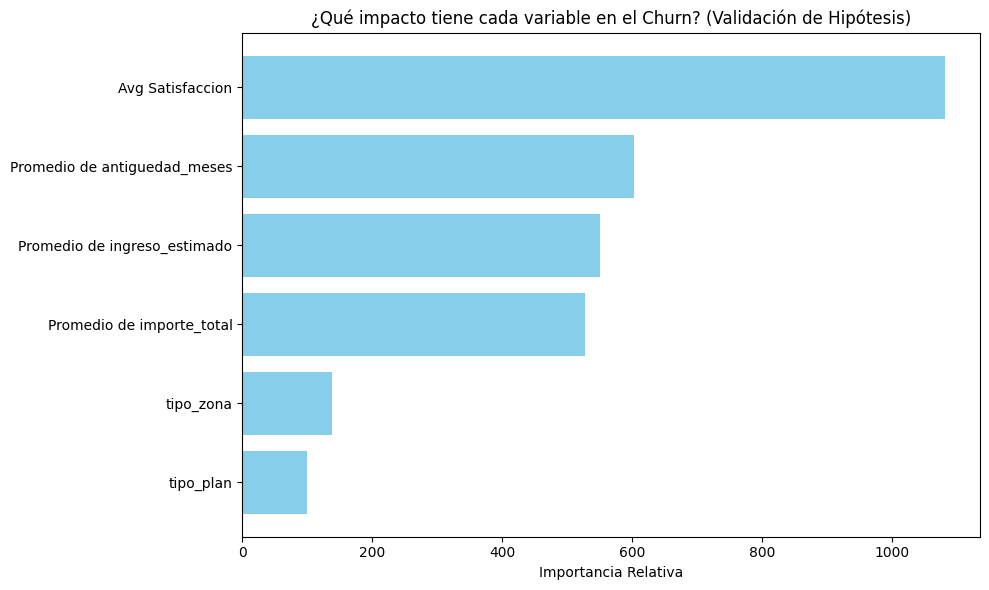

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import joblib  # <--- NUEVO: Para guardar el modelo entrenado

# 1. CARGAR LOS DATOS
df = pd.read_csv(r"C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Modelo_Churn.csv")
df.columns = df.columns.str.strip()

print("Columnas detectadas:", df.columns.tolist())
print("-" * 50)

# --- BLOQUE DE LIMPIEZA OPTIMIZADO ---
# Limpieza de las variables predictoras (X)
columnas_a_numericas = [
    'Promedio de ingreso_estimado', 
    'Promedio de importe_total', 
    'Promedio de antiguedad_meses'
]

for col in columnas_a_numericas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('€', '', regex=False)
        df[col] = df[col].str.replace(' ', '', regex=False)
        df[col] = df[col].str.replace('.', '', regex=False)  # Quita puntos de miles
        df[col] = df[col].str.replace(',', '.', regex=False)  # Cambia coma por punto decimal
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())

# <--- NUEVO: Limpieza estricta del Target (y) por si viene como texto de Power BI
target = 'Suma de churn'
if target in df.columns:
    df[target] = df[target].astype(str).str.replace(' ', '', regex=False)
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df[target] = df[target].fillna(0).astype(int)  # Forzamos a enteros 0 y 1

print("¡Limpieza completada! Tipos de datos actuales:")
print(df[columnas_a_numericas + [target]].dtypes)
print("-" * 50)

# 2. SELECCIÓN DE VARIABLES (FEATURES) Y TARGET
features = [
    'tipo_zona', 
    'Avg Satisfaccion', 
    'tipo_plan', 
    'Promedio de ingreso_estimado', 
    'Promedio de importe_total', 
    'Promedio de antiguedad_meses'
]

X = df[features].copy()
y = df[target].copy()

# 3. PROCESAMIENTO DE VARIABLES CATEGÓRICAS
# <--- NUEVO: Tratamiento de nulos en texto antes de convertirlas en categorías
for col in ['tipo_zona', 'tipo_plan']:
    X[col] = X[col].fillna('No Especificado').astype(str)
    X[col] = X[col].astype('category')

# 4. DIVISIÓN DE DATOS (Entrenamiento 80%, Prueba 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDatos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

# 5. ENTRENAMIENTO DEL MODELO
model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# 6. EVALUACIÓN DEL MODELO
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== REPORTE DE RENDIMIENTO DEL MODELO ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# <--- NUEVO: Matriz de Confusión (Vital para la redacción de la metodología del TFM)
print("\n=== MATRIZ DE CONFUSIÓN ===")
cm = confusion_matrix(y_test, y_pred)
print(f"Verdaderos Activos (TN): {cm[0][0]} | Falsos Fugados (FP): {cm[0][1]}")
print(f"Falsos Activos (FN): {cm[1][0]}     | Verdaderos Fugados (TP): {cm[1][1]}")

# 7. EXTRACCIÓN DE IMPORTANCIA DE LAS VARIABLES
importances = pd.DataFrame({
    'Variable': features,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n=== IMPORTANCIA DE LAS VARIABLES EN EL CHURN ===")
print(importances.to_string(index=False))

# Guardar gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(importances['Variable'], importances['Importancia'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('¿Qué impacto tiene cada variable en el Churn? (Validación de Hipótesis)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.savefig('importancia_variables_tfm.png')
print("\nGráfico de importancia guardado como 'importancia_variables_tfm.png'")

# <--- NUEVO: Exportar el modelo para poder usarlo después en predicciones reales
joblib.dump(model, 'modelo_churn_lightgbm.pkl')
print("Modelo guardado con éxito como 'modelo_churn_lightgbm.pkl'")



¡Gráfico de Matriz de Confusión guardado como 'matriz_confusion_tfm.png'!


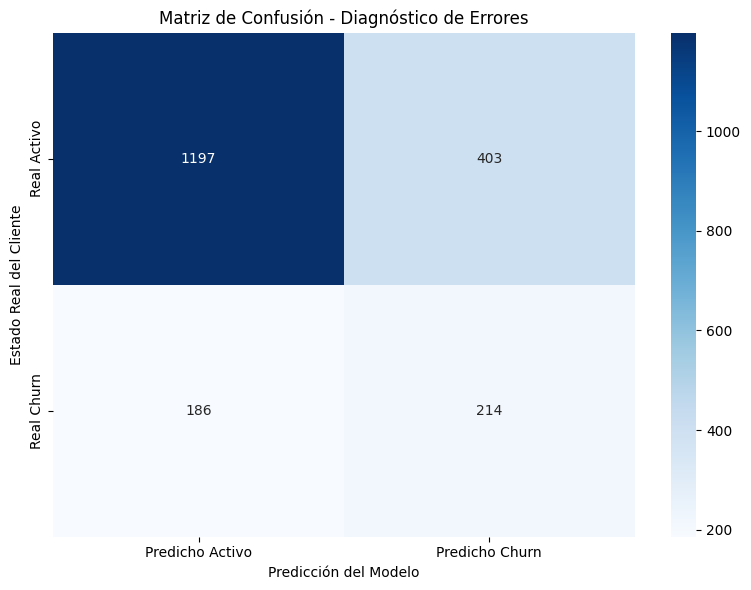

In [54]:
import seaborn as sns

# 8. GRÁFICO DE LA MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))

# Creamos el mapa de calor usando seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicho Activo', 'Predicho Churn'],
            yticklabels=['Real Activo', 'Real Churn'])

plt.title('Matriz de Confusión - Diagnóstico de Errores')
plt.ylabel('Estado Real del Cliente')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()

# Guardamos el gráfico en tu carpeta
plt.savefig('matriz_confusion_tfm.png')
print("\n¡Gráfico de Matriz de Confusión guardado como 'matriz_confusion_tfm.png'!")

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*45)
print(f" 🎯 ACCURACY GLOBAL DEL MODELO: {accuracy * 100:.2f}%")
print("="*45)
print(f" Significa que el modelo clasifica correctamente al {accuracy * 100:.2f}%")
print(f" de los clientes totales dentro del conjunto de prueba.")
print(f" ({np.sum(y_test == y_pred)} aciertos de {len(y_test)} clientes analizados)")
print("-" * 45)


 🎯 ACCURACY GLOBAL DEL MODELO: 70.55%
 Significa que el modelo clasifica correctamente al 70.55%
 de los clientes totales dentro del conjunto de prueba.
 (1411 aciertos de 2000 clientes analizados)
---------------------------------------------


In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import joblib

# 1. CARGAR LOS DATOS CRUDOS EXPORTADOS DE POWER BI
df = pd.read_csv(r"C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Modelo_Churn2.csv")
df.columns = df.columns.str.strip()

# --- TRADUCCIÓN DE MESES EN ESPAÑOL A NÚMEROS ---
# Pasamos primero a minúsculas para que coincida perfectamente con el diccionario
df['Mes'] = df['Mes'].astype(str).str.lower().str.strip()

diccionario_meses = {
    'enero': '01/01/2026',
    'febrero': '01/02/2026',
    'marzo': '01/03/2026',
    'abril': '01/04/2026',
    'mayo': '01/05/2026',
    'junio': '01/06/2026',
    'julio': '01/07/2026',
    'agosto': '01/08/2026',
    'septiembre': '01/09/2026',
    'octubre': '01/10/2026',
    'noviembre': '01/11/2026',
    'diciembre': '01/12/2026'
}

# Reemplazamos las palabras en español por fechas estandarizadas
df['Mes'] = df['Mes'].map(diccionario_meses)

# AHORA SÍ convertimos a formato datetime de forma segura y ordenamos cronológicamente
df['Mes'] = pd.to_datetime(df['Mes'], format='%d/%m/%Y')
df = df.sort_values(by=['cliente_id', 'Mes']).reset_index(drop=True)

print("¡Fechas procesadas con éxito!")
print("Columnas base detectadas:", df.columns.tolist())
print("-" * 50)


# =========================================================================
# ¡INGENIERÍA DE VARIABLES (FEATURE ENGINEERING) DIRECTA EN PYTHON!
# =========================================================================

# 1. Crear 'factura_1': Desplaza el importe total 1 mes hacia adelante por cada cliente
df['factura_1'] = df.groupby('cliente_id')['Suma de importe_total'].shift(1)

# 2. Crear 'factura_mm': Promedio entre la factura actual y la del mes pasado
df['factura_mm'] = (df['Suma de importe_total'] + df['factura_1']) / 2
df['factura_mm'] = df['factura_mm'].fillna(df['Suma de importe_total'])

# 3. Crear 'churn_+1': Mira si el cliente tuvo churn el mes siguiente
df['churn_+1'] = df.groupby('cliente_id')['Suma de churn'].shift(-1)
df['churn_+1'] = df['churn_+1'].fillna(0).astype(int)

# =========================================================================
# ¡FILTRADO DE FILAS CON NAN EN FACTURA_1!
# =========================================================================
# Eliminamos del DataFrame cualquier fila donde 'factura_1' sea NaN 
# (por ejemplo, los meses de enero de cada cliente, que no tienen mes anterior)
df = df.dropna(subset=['factura_1']).reset_index(drop=True)

print(f"Filas restantes en el dataset tras eliminar los NaN de factura_1: {len(df)}")
print("-" * 50)

print("¡Columnas temporales creadas con éxito en VS Code!")
print(df[['cliente_id', 'Mes', 'Suma de importe_total', 'factura_1', 'factura_mm', 'churn_+1']].head(10))
print("-" * 50)
# =========================================================================


# --- BLOQUE DE LIMPIEZA DE FORMATOS ---
columnas_a_limpiar = ['Suma de importe_total', 'factura_1', 'factura_mm', 'Promedio de ingreso_estimado']

for col in columnas_a_limpiar:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('€', '', regex=False)
        df[col] = df[col].str.replace(' ', '', regex=False)
        df[col] = df[col].str.replace('.', '', regex=False)
        df[col] = df[col].str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())


# 2. SELECCIÓN DE VARIABLES ACTUALIZADAS PARA EL MODELO
target = 'churn_+1'

features = [
    'tipo_zona', 
    'Avg Satisfaccion', 
    'tipo_plan', 
    'Promedio de ingreso_estimado', 
    'Suma de importe_total',  
    'factura_1',              
    'factura_mm'              
]

X = df[features].copy()
y = df[target].copy()

# 3. PROCESAMIENTO DE VARIABLES CATEGÓRICAS
for col in ['tipo_zona', 'tipo_plan']:
    X[col] = X[col].fillna('No Especificado').astype(str).astype('category')

# 4. DIVISIÓN DE DATOS, ENTRENAMIENTO Y EVALUACIÓN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("¡Modelo LightGBM entrenado correctamente con tus nuevas variables predictoras!")

¡Fechas procesadas con éxito!
Columnas base detectadas: ['cliente_id', 'Mes', 'tipo_zona', 'Suma de churn', 'Avg Satisfaccion', 'tipo_plan', 'Promedio de ingreso_estimado', 'Suma de importe_total', 'Promedio de antiguedad_meses']
--------------------------------------------------
Filas restantes en el dataset tras eliminar los NaN de factura_1: 27361
--------------------------------------------------
¡Columnas temporales creadas con éxito en VS Code!
  cliente_id        Mes  Suma de importe_total  factura_1  factura_mm  \
0    C000001 2026-02-01                15953.0    14573.0     15263.0   
1    C000001 2026-03-01                16727.0    15953.0     16340.0   
2    C000001 2026-04-01                11673.0    16727.0     14200.0   
3    C000001 2026-05-01                12950.0    11673.0     12311.5   
4    C000001 2026-06-01                17790.0    12950.0     15370.0   
5    C000001 2026-07-01                16480.0    17790.0     17135.0   
6    C000001 2026-08-01           

In [57]:
df


,cliente_id,Mes,tipo_zona,Suma de churn,Avg Satisfaccion,tipo_plan,Promedio de ingreso_estimado,Suma de importe_total,Promedio de antiguedad_meses,factura_1,factura_mm,churn_+1
0,C000001,2026-02-01,urbana_premium,0,34.0,Prepago,43350.000000,159530.000000,"720,00",145730,152630.000000,0
1,C000001,2026-03-01,urbana_premium,0,32.5,Prepago,43350.000000,167270.000000,"720,00",159530,163400.000000,0
2,C000001,2026-04-01,urbana_premium,0,45.0,Prepago,43350.000000,116730.000000,"720,00",167270,142000.000000,0
3,C000001,2026-05-01,urbana_premium,0,30.0,Prepago,43350.000000,129500.000000,"720,00",116730,123115.000000,0
4,C000001,2026-06-01,urbana_premium,0,30.0,Prepago,43350.000000,177900.000000,"720,00",129500,153700.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27356,C002577,2026-04-01,suburbana,0,20.0,Premium,26210.000000,320117.445694,"810,00",327130,320762.421334,0
27357,C002577,2026-06-01,suburbana,0,NaN,Premium,34568.127922,32550.000000,NaN,32800,32675.000000,0
27358,C002577,2026-07-01,suburbana,0,50.0,Premium,26210.000000,324650.000000,"810,00",32550,178600.000000,0
27359,C002577,2026-08-01,suburbana,0,35.0,Premium,26210.000000,323680.000000,"810,00",324650,324165.000000,1


In [58]:
target = 'churn_+1'
features = [
    'tipo_zona', 'Avg Satisfaccion', 'tipo_plan', 
    'Promedio de ingreso_estimado', 'Suma de importe_total', 
    'factura_1', 'factura_mm'
]

X = df[features].copy()
y = df[target].copy()

# Tratamiento de variables categóricas para LightGBM
for col in ['tipo_zona', 'tipo_plan']:
    X[col] = X[col].fillna('No Especificado').astype(str).astype('category')


# 5. DIVISIÓN DE DATOS Y ENTRENAMIENTO DEL MODELO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Configuración del clasificador con pesos balanceados para mitigar el desfase de clases
model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("¡Modelo LightGBM entrenado exitosamente con las variables temporales procesadas!")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 342, number of negative: 21546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1106
[LightGBM] [Info] Number of data points in the train set: 21888, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
¡Modelo LightGBM entrenado exitosamente con las variables temporales procesadas!



       REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      5388
           1       0.04      0.36      0.07        85

    accuracy                           0.84      5473
   macro avg       0.51      0.61      0.49      5473
weighted avg       0.97      0.84      0.90      5473

ROC AUC Score: 0.6479



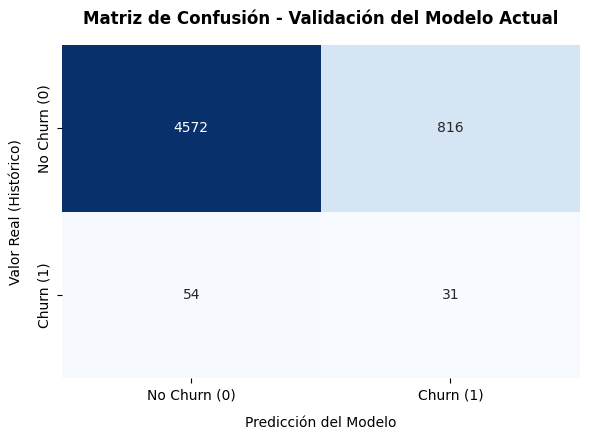

¡Evaluación completada! El gráfico de la matriz se ha mostrado en pantalla y guardado en tu directorio.


In [59]:
# 1. Realizar las predicciones utilizando el conjunto de prueba (X_test)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Imprimir el informe de métricas principales en consola
print("\n" + "="*40)
print("       REPORTE DE CLASIFICACIÓN")
print("="*40)
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*40 + "\n")

# 3. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Generar el gráfico visual (Heatmap) para la memoria del TFM
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'], 
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.title('Matriz de Confusión - Validación del Modelo Actual', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=10, labelpad=10)
plt.ylabel('Valor Real (Histórico)', fontsize=10, labelpad=10)
plt.tight_layout()

# 5. Guardar la imagen automáticamente en tu carpeta de reportes
plt.savefig(r"C:\Users\William\Documents\UCV-Churn\reports\figures\matriz_confusion_actual.png", dpi=300)
plt.show()

print("¡Evaluación completada! El gráfico de la matriz se ha mostrado en pantalla y guardado en tu directorio.")

In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*45)
print(f" 🎯 ACCURACY GLOBAL DEL MODELO: {accuracy * 100:.2f}%")
print("="*45)
print(f" Significa que el modelo clasifica correctamente al {accuracy * 100:.2f}%")
print(f" de los clientes totales dentro del conjunto de prueba.")
print(f" ({np.sum(y_test == y_pred)} aciertos de {len(y_test)} clientes analizados)")
print("-" * 45)


 🎯 ACCURACY GLOBAL DEL MODELO: 84.10%
 Significa que el modelo clasifica correctamente al 84.10%
 de los clientes totales dentro del conjunto de prueba.
 (4603 aciertos de 5473 clientes analizados)
---------------------------------------------


In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import joblib

# 1. CARGAR LOS DATOS CRUDOS EXPORTADOS DE POWER BI
df3 = pd.read_csv(r"C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Modelo_Churn2.csv")
df3.columns = df3.columns.str.strip()

# --- TRADUCCIÓN DE MESES EN ESPAÑOL A NÚMEROS ---
df3['Mes'] = df3['Mes'].astype(str).str.lower().str.strip()

diccionario_meses = {
    'enero': '01/01/2026', 'febrero': '01/02/2026', 'marzo': '01/03/2026',
    'abril': '01/04/2026', 'mayo': '01/05/2026', 'junio': '01/06/2026',
    'julio': '01/07/2026', 'agosto': '01/08/2026', 'septiembre': '01/09/2026',
    'octubre': '01/10/2026', 'noviembre': '01/11/2026', 'diciembre': '01/12/2026'
}

df3['Mes'] = df3['Mes'].map(diccionario_meses)
df3['Mes'] = pd.to_datetime(df3['Mes'], format='%d/%m/%Y')
df3 = df3.sort_values(by=['cliente_id', 'Mes']).reset_index(drop=True)

print("¡Fechas procesadas con éxito!")
print("Columnas base detectadas:", df3.columns.tolist()) # <-- CORREGIDO: df3
print("-" * 50)


# =========================================================================
# ¡INGENIERÍA DE VARIABLES (FEATURE ENGINEERING) DIRECTA EN PYTHON!
# =========================================================================

# 1. Crear 'factura_1': Desplaza el importe total 1 mes hacia adelante
df3['factura_1'] = df3.groupby('cliente_id')['Suma de importe_total'].shift(1)

# 2. Crear 'factura_mm': Promedio móvil
df3['factura_mm'] = (df3['Suma de importe_total'] + df3['factura_1']) / 2
df3['factura_mm'] = df3['factura_mm'].fillna(df3['Suma de importe_total']) # <-- CORREGIDO: df3

# 3. Crear 'churn_+3': ¿Habrá churn en cualquiera de los próximos 3 meses?
# Primero invertimos el orden cronológico del grupo para simular que miramos al futuro con un rolling hacia atrás
df3['churn_+3'] = (
    df3.iloc[::-1]  # Invierte el df temporalmente
    .groupby('cliente_id')['Suma de churn']
    .rolling(window=3, min_periods=1) # Agrupa en ventanas de 3 meses futuros
    .max() # Si en alguno de los 3 meses hay un '1', el resultado será '1'
    .reset_index(level=0, drop=True)
)
# El último shift(-1) es para asegurar que NO incluya el mes actual en la predicción del futuro
df3['churn_+3'] = df3.groupby('cliente_id')['churn_+3'].shift(-1)
df3['churn_+3'] = df3['churn_+3'].fillna(0).astype(int)

# =========================================================================
# ¡FILTRADO DE FILAS CON NAN EN FACTURA_1!
# =========================================================================
df3 = df3.dropna(subset=['factura_1']).reset_index(drop=True)

print(f"Filas restantes en el dataset tras eliminar los NaN de factura_1: {len(df3)}")
print("-" * 50)


# --- BLOQUE DE LIMPIEZA DE FORMATOS ---
columnas_a_limpiar = ['Suma de importe_total', 'factura_1', 'factura_mm', 'Promedio de ingreso_estimado']

for col in columnas_a_limpiar:
    if col in df3.columns: # <-- CORREGIDO: df3
        df3[col] = df3[col].astype(str).str.replace('€', '', regex=False)
        df3[col] = df3[col].str.replace(' ', '', regex=False)
        df3[col] = df3[col].str.replace('.', '', regex=False)
        df3[col] = df3[col].str.replace(',', '.', regex=False)
        df3[col] = pd.to_numeric(df3[col], errors='coerce') # <-- CORREGIDO: df3
        df3[col] = df3[col].fillna(df3[col].mean()) # <-- CORREGIDO: df3


# 2. SELECCIÓN DE VARIABLES ACTUALIZADAS PARA EL MODELO
target = 'churn_+3'

features = [
    'tipo_zona', 
    'Avg Satisfaccion', 
    'tipo_plan', 
    'Promedio de ingreso_estimado', 
    'Suma de importe_total',  
    'factura_1',              
    'factura_mm'              
]

X = df3[features].copy()
y = df3[target].copy()

# 3. PROCESAMIENTO DE VARIABLES CATEGÓRICAS
for col in ['tipo_zona', 'tipo_plan']:
    X[col] = X[col].fillna('No Especificado').astype(str).astype('category')

# 4. DIVISIÓN DE DATOS, ENTRENAMIENTO Y EVALUACIÓN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("¡Modelo LightGBM entrenado correctamente para predecir Churn a la redonda de 3 meses!")

¡Fechas procesadas con éxito!
Columnas base detectadas: ['cliente_id', 'Mes', 'tipo_zona', 'Suma de churn', 'Avg Satisfaccion', 'tipo_plan', 'Promedio de ingreso_estimado', 'Suma de importe_total', 'Promedio de antiguedad_meses']
--------------------------------------------------
Filas restantes en el dataset tras eliminar los NaN de factura_1: 27361
--------------------------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 943, number of negative: 20945
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1107
[LightGBM] [Info] Number of data points in the train set: 21888, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
¡Modelo LightGBM entrenad


       REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      5237
           1       0.12      0.64      0.21       236

    accuracy                           0.79      5473
   macro avg       0.55      0.72      0.54      5473
weighted avg       0.94      0.79      0.85      5473

ROC AUC Score: 0.7974



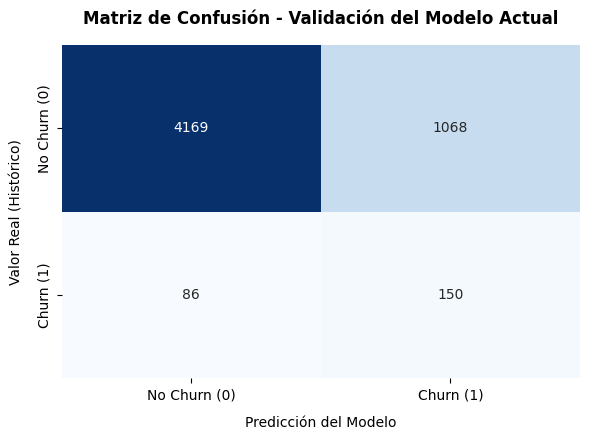

¡Evaluación completada! El gráfico de la matriz se ha mostrado en pantalla y guardado en tu directorio.


In [62]:
# 1. Realizar las predicciones utilizando el conjunto de prueba (X_test)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Imprimir el informe de métricas principales en consola
print("\n" + "="*40)
print("       REPORTE DE CLASIFICACIÓN")
print("="*40)
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*40 + "\n")

# 3. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Generar el gráfico visual (Heatmap) para la memoria del TFM
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'], 
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.title('Matriz de Confusión - Validación del Modelo Actual', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=10, labelpad=10)
plt.ylabel('Valor Real (Histórico)', fontsize=10, labelpad=10)
plt.tight_layout()

# 5. Guardar la imagen automáticamente en tu carpeta de reportes
plt.savefig(r"C:\Users\William\Documents\UCV-Churn\reports\figures\matriz_confusion_actual.png", dpi=300)
plt.show()

print("¡Evaluación completada! El gráfico de la matriz se ha mostrado en pantalla y guardado en tu directorio.")

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*45)
print(f" 🎯 ACCURACY GLOBAL DEL MODELO: {accuracy * 100:.2f}%")
print("="*45)
print(f" Significa que el modelo clasifica correctamente al {accuracy * 100:.2f}%")
print(f" de los clientes totales dentro del conjunto de prueba.")
print(f" ({np.sum(y_test == y_pred)} aciertos de {len(y_test)} clientes analizados)")
print("-" * 45)


 🎯 ACCURACY GLOBAL DEL MODELO: 78.91%
 Significa que el modelo clasifica correctamente al 78.91%
 de los clientes totales dentro del conjunto de prueba.
 (4319 aciertos de 5473 clientes analizados)
---------------------------------------------


In [64]:
# =========================================================================
# GENERAR Y DESCARGAR EL ARCHIVO CSV CON LAS PREDICCIONES
# =========================================================================

# 1. Calculamos las predicciones para TODO el dataset procesado (o puedes usar X_test si solo quieres la validación)
df3['Prediccion_Churn_3M'] = model.predict(X)

# 2. Calculamos la probabilidad exacta (da un valor entre 0 y 1, lo multiplicamos por 100 para tener el porcentaje)
df3['Probabilidad_Churn_%'] = np.round(model.predict_proba(X)[:, 1] * 100, 2)

# 3. Seleccionamos las columnas clave que te interesan
columnas_resultado = [
   
    'Mes', 
    'Suma de importe_total', 
    'factura_1',
    'Avg Satisfaccion',
    'Probabilidad_Churn_%', 
    'Prediccion_Churn_3M'
]

df_final = df3[columnas_resultado].copy()

# 4. Definimos la ruta de descarga (puedes guardarlo en tu misma carpeta de datasets)
ruta_descarga = r"C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Resultado_Predicciones_Churn3M.csv"

# 5. Exportamos a CSV de forma limpia (index=False evita que se agregue una columna de números innecesaria)
df_final.to_csv(ruta_descarga, index=False, encoding='utf-8-sig')

print(f"¡Éxito! El archivo CSV se ha descargado correctamente en:")
print(ruta_descarga)
print("\nVista previa de los primeros resultados:")
print(df_final.head())

¡Éxito! El archivo CSV se ha descargado correctamente en:
C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Resultado_Predicciones_Churn3M.csv

Vista previa de los primeros resultados:
         Mes  Suma de importe_total  factura_1  Avg Satisfaccion  \
0 2026-02-01               159530.0     145730              34.0   
1 2026-03-01               167270.0     159530              32.5   
2 2026-04-01               116730.0     167270              45.0   
3 2026-05-01               129500.0     116730              30.0   
4 2026-06-01               177900.0     129500              30.0   

   Probabilidad_Churn_%  Prediccion_Churn_3M  
0                 15.88                    0  
1                 12.06                    0  
2                 22.53                    0  
3                 30.83                    0  
4                 25.07                    0  


In [65]:
# =========================================================================
# EXPORTAR EL DATASET ORIGINAL COMPLETO CON LA COLUMNA DE PREDICCIÓN
# =========================================================================

# 1. Calculamos la predicción para todas las filas del dataframe actual
df3['Prediccion_Churn_3M'] = model.predict(X)

# En las filas que eliminamos antes de entrenar (los NaN de factura_1), 
# por lógica de negocio el modelo no pudo predecir; les asignamos 0 por defecto
df3['Prediccion_Churn_3M'] = df3['Prediccion_Churn_3M'].fillna(0).astype(int)

# 2. Definimos la ruta de destino para guardar tu archivo
ruta_descarga = r"C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Resultado_Predicciones_Churn3M.csv"

# 3. Descargamos el CSV completo, tal cual estaba, manteniendo todas tus columnas intactas
df3.to_csv(ruta_descarga, index=False, encoding='utf-8-sig')

print(f"¡Éxito! El archivo original con la nueva columna se ha guardado en:")
print(ruta_descarga)

¡Éxito! El archivo original con la nueva columna se ha guardado en:
C:\Users\William\Documents\UCV-Churn\data\raw\dataset\Resultado_Predicciones_Churn3M.csv


In [66]:
df3.head()

,cliente_id,Mes,tipo_zona,Suma de churn,Avg Satisfaccion,tipo_plan,Promedio de ingreso_estimado,Suma de importe_total,Promedio de antiguedad_meses,factura_1,factura_mm,churn_+3,Prediccion_Churn_3M,Probabilidad_Churn_%
0,C000001,2026-02-01,urbana_premium,0,34.0,Prepago,43350.0,159530.0,"720,00",145730,152630.0,0,0,15.88
1,C000001,2026-03-01,urbana_premium,0,32.5,Prepago,43350.0,167270.0,"720,00",159530,163400.0,0,0,12.06
2,C000001,2026-04-01,urbana_premium,0,45.0,Prepago,43350.0,116730.0,"720,00",167270,142000.0,0,0,22.53
3,C000001,2026-05-01,urbana_premium,0,30.0,Prepago,43350.0,129500.0,"720,00",116730,123115.0,0,0,30.83
4,C000001,2026-06-01,urbana_premium,0,30.0,Prepago,43350.0,177900.0,"720,00",129500,153700.0,0,0,25.07


In [67]:
from sklearn.metrics import accuracy_score

# =========================================================================
# CALCULAR EL ACCURACY GLOBAL DEL MODELO
# =========================================================================

# 1. Aseguramos que tenemos tanto las etiquetas reales como las predicciones
# 'y' contiene el churn real a 3 meses y 'X' contiene los datos con los que predice el modelo
y_real = df3[target]
y_predichas = model.predict(X)

# 2. Calculamos el accuracy score
accuracy = accuracy_score(y_real, y_predichas)

print("\n" + "="*40)
print(f" ACCURACY GLOBAL DEL MODELO: {accuracy * 100:.2f}%")
print("="*40)
print(f"Significa que el modelo acierta {np.sum(y_real == y_predichas)} de {len(df3)} filas analizadas.")
print("-" * 40)


 ACCURACY GLOBAL DEL MODELO: 80.58%
Significa que el modelo acierta 22047 de 27361 filas analizadas.
----------------------------------------
